In [ ]:
import os

from dotenv import load_dotenv
from typing import Literal, Annotated
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END  
from langgraph.checkpoint.memory import InMemorySaver

In [ ]:
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
import operator

In [29]:
load_dotenv()

True

In [30]:
llm1 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY1']
    # other params...
)

llm2 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY2']
    # other params...
)

llm3 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY3']
    # other params...
)

Key takeaway

A StateGraph always works with a state object. During execution, each node returns only the changes (a partial dictionary), and LangGraph merges those changes into the current state. When the graph reaches END, workflow.invoke() returns the final merged state, which is typically a Python dict containing all the state values accumulated throughout the workflow.

In [31]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [32]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm2.invoke(messages)

    # response store state
    return {'messages': [response]}

In [ ]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

NameError: name 'StateGraph' is not defined

: 

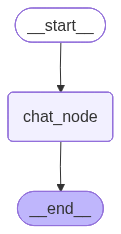

In [34]:
chatbot

In [35]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

final_state = chatbot.invoke(initial_state)
print(type(final_state))


<class 'dict'>


In [19]:
print(final_state)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='294dd06d-1bc1-46c3-831e-932d0d802785'), AIMessage(content="The capital of India is **New Delhi**, which is a part of the **National Capital Territory (NCT) of Delhi**. \n\n**Key Points:**\n- **New Delhi** serves as the **political and administrative capital** of India.\n- It is located within the **Delhi metropolitan area**, which includes the historic city of Delhi and surrounding regions.\n- The NCT of Delhi is a **federal territory** with a special status, governed directly by the Union Government of India.\n- New Delhi became the capital in **1911**, replacing Calcutta (now Kolkata), and has since been the center of India's governance.\n\nLet me know if you'd like additional details! 🇮🇳", additional_kwargs={'reasoning_content': 'Okay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New

In [21]:
print(final_state['messages'])

[HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='294dd06d-1bc1-46c3-831e-932d0d802785'), AIMessage(content="The capital of India is **New Delhi**, which is a part of the **National Capital Territory (NCT) of Delhi**. \n\n**Key Points:**\n- **New Delhi** serves as the **political and administrative capital** of India.\n- It is located within the **Delhi metropolitan area**, which includes the historic city of Delhi and surrounding regions.\n- The NCT of Delhi is a **federal territory** with a special status, governed directly by the Union Government of India.\n- New Delhi became the capital in **1911**, replacing Calcutta (now Kolkata), and has since been the center of India's governance.\n\nLet me know if you'd like additional details! 🇮🇳", additional_kwargs={'reasoning_content': 'Okay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the

In [16]:
uttar = llm2.invoke('WHat is capital of India??')
print(uttar)

content="The capital of India is **New Delhi**. It is a part of the **National Capital Territory (NCT) of Delhi**, which is a union territory of India. New Delhi serves as the **political and administrative center** of the country, housing key government institutions such as the **Parliament of India**, the **Supreme Court**, and the **President's official residence** (Rashtrapati Bhavan). \n\nWhile **Delhi** is the larger metropolitan area, **New Delhi** is the specific city within it that functions as the capital. Mumbai, the most populous city in India, is the financial hub but not the capital. \n\nLet me know if you'd like additional details! 🇮🇳" additional_kwargs={'reasoning_content': "Okay, so the user is asking for the capital of India. Let me start by recalling what I know. I remember that India is a country in South Asia. The capital isn't the most populous city, which is Mumbai, I think. The capital is usually a city where the government is based.\n\nWait, I think the capital

In [41]:
thread_id = '1'

while True:

    user_inp = input("User_input ")
    print('User ' , user_inp)

    if user_inp.strip().lower() in ['exit', 'bye', 'quit']:
        break
    
    config1 = {'configurable' : {'thread_id' : thread_id}}
    response = chatbot.invoke({'messages' : HumanMessage(content=user_inp)}, config = config1)
    print("AI : ", response['messages'][-1])

User  hello myself rohit
AI :  content='Hello Rohit! Nice to meet you. How can I assist you today? 😊' additional_kwargs={'reasoning_content': 'Okay, the user said, "hello myself rohit." Let me break this down. They\'re introducing themselves as Rohit. The phrase "hello myself" is a bit unusual. Maybe they meant to say "Hello, I\'m Rohit" or "Hello, my name is Rohit." It\'s possible they made a typo or phrased it differently.\n\nI should acknowledge their introduction and respond warmly. Since they mentioned their name, I can use it in the response to make it more personal. Also, I should ask how I can assist them to keep the conversation going. Let me check if there\'s any other nuance I might be missing. The user might be testing if I can handle informal or slightly incorrect phrasing, so a friendly and helpful response is key here. Alright, time to craft a reply that\'s welcoming and open-ended.\n'} response_metadata={'token_usage': {'completion_tokens': 196, 'prompt_tokens': 12, 'to

In [49]:
chatbot.get_state(config = config1)

ValueError: No checkpointer set